In [1]:
import pandas as pd
import torch
import re
from collections import Counter
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import math
import torch.optim as optim
from tqdm import tqdm
import math, torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [3]:
#Separate the first dataset in two columns
df=pd.read_csv("dialogs.txt", sep="\t", header=None, names=["Context", "Reply"], encoding="utf-8", engine="python", on_bad_lines="skip")
df

,Context,Reply
0,"hi, how are you doing?",i'm fine. how about yourself?
1,i'm fine. how about yourself?,i'm pretty good. thanks for asking.
2,i'm pretty good. thanks for asking.,no problem. so how have you been?
3,no problem. so how have you been?,i've been great. what about you?
4,i've been great. what about you?,i've been good. i'm in school right now.
...,...,...
3718,that's a good question. maybe it's not old age.,are you right-handed?
3719,are you right-handed?,yes. all my life.
3720,yes. all my life.,you're wearing out your right hand. stop using...
3721,you're wearing out your right hand. stop using...,but i do all my writing with my right hand.


In [7]:
df1=pd.read_csv("dialogues_text.txt", sep="\t", header=None, encoding="utf-8", names=["Text"], engine="python", on_bad_lines="skip")
len(df1)

13118

In [9]:
#Separate the second dataset in two columns
context = []
replies = []

for text in df1["Text"]:

    parts = text.strip().split("__eou__")

    parts = [p.strip() for p in parts if p.strip()]

    for i in range(len(parts) - 1):
        context.append(parts[i])
        replies.append(parts[i + 1])

df_new = pd.DataFrame({
    "Context": context,
    "Reply": replies
})
df_new

In [13]:
#Concat the two datasets
df_all=pd.concat([df, df_new], ignore_index=True)
df_all

,Context,Reply
0,"hi, how are you doing?",i'm fine. how about yourself?
1,i'm fine. how about yourself?,i'm pretty good. thanks for asking.
2,i'm pretty good. thanks for asking.,no problem. so how have you been?
3,no problem. so how have you been?,i've been great. what about you?
4,i've been great. what about you?,i've been good. i'm in school right now.
...,...,...
93580,"Oh , lots of them . For instance , War Risks ,...","Well , thank you very much for all that inform..."
93581,"Well , thank you very much for all that inform...",Are you going to make an offer today ?
93582,Are you going to make an offer today ?,Yes . My customer is in urgent need of the ste...
93583,Yes . My customer is in urgent need of the ste...,"Ok , I'll get this rate right away ."


In [15]:
#Data preprocesing
import re
import pandas as pd

def clean_text(text):
    text = text.lower().strip()                        # lowercase and trim spaces
    text = re.sub(r"<.*?>", " ", text)                 # remove HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)        # remove URLs
    text = re.sub(r"[^a-z0-9\s.,!?':]", " ", text)     # keep common chars + colon
    text = re.sub(r"\s+", " ", text)                   # collapse multiple spaces
    return text.strip()

# clean both columns
df_all["Context"] = df_all["Context"].astype(str).apply(clean_text)
df_all["Reply"]   = df_all["Reply"].astype(str).apply(clean_text)

# create one text column for GPT-style training
df_all["Text"] = "user: " + df_all["Context"] + "\nassistant: " + df_all["Reply"]

df_all.head()

,Context,Reply,Text
0,"hi, how are you doing?",i'm fine. how about yourself?,"user: hi, how are you doing?\nassistant: i'm f..."
1,i'm fine. how about yourself?,i'm pretty good. thanks for asking.,user: i'm fine. how about yourself?\nassistant...
2,i'm pretty good. thanks for asking.,no problem. so how have you been?,user: i'm pretty good. thanks for asking.\nass...
3,no problem. so how have you been?,i've been great. what about you?,user: no problem. so how have you been?\nassis...
4,i've been great. what about you?,i've been good. i'm in school right now.,user: i've been great. what about you?\nassist...


In [18]:
#Tokenazation
def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())
    

In [20]:
# Build vocab from the merged text column
all_text = " ".join(df_all["Text"].tolist())
tokens = tokenize(all_text)

vocab = {word: i + 2 for i, word in enumerate(sorted(set(tokens)))}

vocab["<UNK>"] = 0
vocab["<EOS>"] = 1

print("Vocab size:", len(vocab))
                  

Vocab size: 18789


In [22]:
#Encode function
def encode(sentence, vocab, add_eos=True):
    tokens = tokenize(sentence)
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]

    if add_eos:
        ids.append(vocab["<EOS>"])

    return ids
    

In [24]:
df_all["ids"] = df_all["Text"].apply(lambda x: encode(x, vocab, add_eos=True))
df_all['ids']

0        [17752, 829, 8243, 4, 8494, 1582, 18710, 5515,...
1        [17752, 829, 8594, 3, 10279, 6843, 5, 8494, 86...
2        [17752, 829, 8594, 3, 10279, 13013, 7630, 5, 1...
3        [17752, 829, 11475, 13077, 5, 15468, 8494, 810...
4        [17752, 829, 8594, 3, 17838, 2138, 7760, 5, 18...
                               ...                        
93580    [17752, 829, 11690, 4, 10188, 11661, 16833, 5,...
93581    [17752, 829, 18267, 4, 16804, 18710, 17896, 11...
93582    [17752, 829, 1582, 18710, 7617, 17043, 10369, ...
93583    [17752, 829, 18686, 5, 11237, 4730, 9156, 8737...
93584    [17752, 829, 11704, 4, 8594, 3, 10095, 7522, 1...
Name: ids, Length: 93585, dtype: object

In [35]:
#Split train and test data
from sklearn.model_selection import train_test_split
train_df, val_df=train_test_split(df_all, test_size=0.1, random_state=42, shuffle=True)


In [37]:
#Function to creat the block size chunks that will deliver for training
block_size=128
buffer=[]
def pack_token(new_tokens, block_size=block_size):
    global buffer
    chunks=[]
    
    buffer.extend(new_tokens)
    
    while len(buffer)>=block_size:
        chunk=buffer[:block_size]
        
        input_ids=chunk[:-1]
        labels=chunk[1:]

        
        chunks.append({"input_ids": input_ids, "labels": labels})
        buffer=buffer[block_size:]
        
    return chunks

In [39]:
#Training chunks
train_chunks=[]
buffer=[]
for ids in train_df["ids"]:
    chunks=pack_token(ids)
    train_chunks.extend(chunks)

In [41]:
#Testing chunks
val_chunks=[]
buffer=[]
for ids in val_df['ids']:
    chunks=pack_token(ids)
    val_chunks.extend(chunks)

In [43]:
#
class PackedDataset(Dataset):
    def __init__(self, chunks):
        self.chunks=chunks
        
    def __len__(self):
        return len(self.chunks)
        
    def __getitem__(self, idx):
        item=self.chunks[idx]
        
        return (
            torch.tensor(item["input_ids"], dtype=torch.long),
            torch.tensor(item["labels"], dtype=torch.long)
        )

train_ds=PackedDataset(train_chunks)
val_ds=PackedDataset(val_chunks)

train_dl=DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl=DataLoader(val_ds, batch_size=16, shuffle=False)


In [46]:
#Calculating the position of each token with sinusoidal position encoding method
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)          # (T, 1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32)*(-math.log(10000.0) / d_model))                          # (d_model/2,)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                                                       # (1, T, d_model)
        self.register_buffer("pe", pe)                                             # not a parameter

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        T = x.size(1)
        return x + self.pe[:, :T, :]


In [48]:
#Calculating the position of each token with learned position encoding method
class LearnedPositionEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()

        self.pos_emb = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.size()
        position = torch.arange(T, device=x.device).unsqueeze(0)   # (1, T)
        pos_encoding = self.pos_emb(position)                      # (1, T, D)
        x = x + pos_encoding
        return self.dropout(x)        

In [50]:
#The causal attention mask computation
def causal_attn_mask(T, device=None):
    return torch.triu(torch.ones(T, T, dtype=torch.bool, device=device), diagonal=1)
    

In [52]:
# --- The model ---
class CausalTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, n_layers=6, d_ff=2048, dropout=0.1):
        super().__init__()
       

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = SinusoidalPositionalEncoding(d_model)
        self.dropout = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.decoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids: torch.Tensor):
        B, T=input_ids.shape
        device=input_ids.device
        x=self.tok_emb(input_ids)
        x=self.pos_enc(x)
        x=self.dropout(x)
        causal_mask=causal_attn_mask(T, device=device)

        h=self.decoder(x, mask=causal_mask)

        logits=self.lm_head(h)
        return logits

        

In [54]:
#Function to evaluete the model
def evaluate(model, data_loader, device, criterion, desc=None):
    model.eval()
    total_loss=0
    total_correct=0
    total_examples=0
    pbar=tqdm(data_loader, desc=desc) if desc else data_loader
    
    for inputs, labels in pbar:
        inputs=inputs.to(device)
        labels=labels.to(device)
        logits=model(inputs)
        
        loss=criterion(logits.transpose(1, 2), labels)
        
        total_loss+=loss.item() * labels.numel()
        
        preds=torch.argmax(logits, dim=-1)
        total_correct += (preds==labels).sum().item()
        total_examples += labels.numel()
        
        
    average_loss=total_loss / max(1, total_examples)
    accuracy=total_correct / max(1, total_examples)

    return average_loss, accuracy
        

In [56]:
#Function to train the model
def train(model, train_loader, val_loader, device, epochs=5, lr=3e-4, weight_decay=0.01):
    criterion=nn.CrossEntropyLoss()
    optimizer=torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(
    optimizer,
    T_max=epochs)
        

    
    hystory={"train_loss": [],
            "train_accuracy": [], 
            "val_loss": [], 
            "val_accuracy": []}
    
    best_value_accuracy=-1
    best_path="best_path.pt"
    
    for epoch in range(1, epochs+1):
        model.train()
        total_loss=0
        total_corect=0
        total_exemples=0
        pbar=tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        
        for inputs, labels in pbar:
            inputs=inputs.to(device)
            labels=labels.to(device)
            
            optimizer.zero_grad(set_to_none=True)
            
            logits=model(inputs)
            loss=criterion(logits.transpose(1,2), labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.step()
            scheduler.step()
            
        
            total_loss+=loss.item() * labels.numel()
            
            pred=torch.argmax(logits, dim=-1)
            total_corect+=(pred==labels).sum().item()
            total_exemples+=labels.numel()
            
            avg_loss_so_far=total_loss/max(1, total_exemples)
            avg_accuracy_so_far=total_corect/max(1, total_exemples)

            pbar.set_postfix(loss=f"{avg_loss_so_far:.4f}", acc=f"{avg_accuracy_so_far:.4f}")
            
        train_loss=total_loss/max(1, total_exemples)
        train_accuracy=total_corect/max(1, total_exemples)
        val_loss, val_accuracy = evaluate(model, val_loader, device, criterion, desc="Validation")
        
        hystory["train_loss"].append(train_loss)
        hystory["train_accuracy"].append(train_accuracy)
        hystory["val_loss"].append(val_loss)
        hystory["val_accuracy"].append(val_accuracy)
        print(f"Epoch: {epoch} Train Loss: {train_loss:.3f} Train Accuracy: {train_accuracy:.2f}, Val Loss: {val_loss:.3f}, Val Accuraccy: {val_accuracy:.3f}")
        
        if val_accuracy>best_value_accuracy:
            best_value_accuracy=val_accuracy
            torch.save({"model_state_dict":model.state_dict(), "best_val_acc": best_value_accuracy,}, best_path)
            print(f"Saved the best model to: {best_path} (val_acc={best_value_accuracy:.4f})")
        
    return hystory, best_path     

In [58]:
vocab_size=len(vocab)

In [73]:
#The classification model
model=CausalTransformerLM(vocab_size=vocab_size, d_model=512, n_heads=8, n_layers=6, d_ff=2048, dropout=0.1).to(device)

/var/folders/xg/4zdj6pfn5jx2rq8rgj0f9m840000gn/T/ipykernel_89488/2294769071.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


In [75]:
history, best_path = train(model, train_dl, val_dl, device, epochs=10, lr=3e-4)

Validation: 100%|██████████| 155/155 [00:04<00:00, 35.46it/s]


Epoch: 1 Train Loss: 3.880 Train Accuracy: 0.34, Val Loss: 3.373, Val Accuraccy: 0.383
Saved the best model to: best_path.pt (val_acc=0.3826)


Validation: 100%|██████████| 155/155 [00:04<00:00, 31.48it/s]


Epoch: 2 Train Loss: 3.179 Train Accuracy: 0.39, Val Loss: 3.078, Val Accuraccy: 0.406
Saved the best model to: best_path.pt (val_acc=0.4059)


Validation: 100%|██████████| 155/155 [00:04<00:00, 33.18it/s]


...

Epoch: 8 Train Loss: 2.057 Train Accuracy: 0.52, Val Loss: 2.403, Val Accuraccy: 0.499
Saved the best model to: best_path.pt (val_acc=0.4987)


Validation: 100%|██████████| 155/155 [00:04<00:00, 33.61it/s]


Epoch: 9 Train Loss: 1.963 Train Accuracy: 0.54, Val Loss: 2.339, Val Accuraccy: 0.512
Saved the best model to: best_path.pt (val_acc=0.5125)


Validation: 100%|██████████| 155/155 [00:04<00:00, 32.77it/s]


Epoch: 10 Train Loss: 1.883 Train Accuracy: 0.55, Val Loss: 2.297, Val Accuraccy: 0.521
Saved the best model to: best_path.pt (val_acc=0.5213)


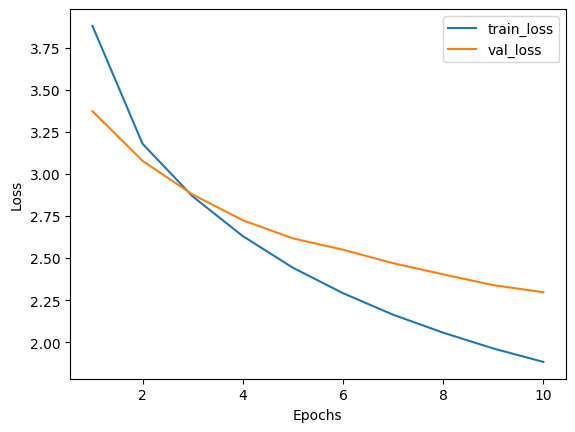

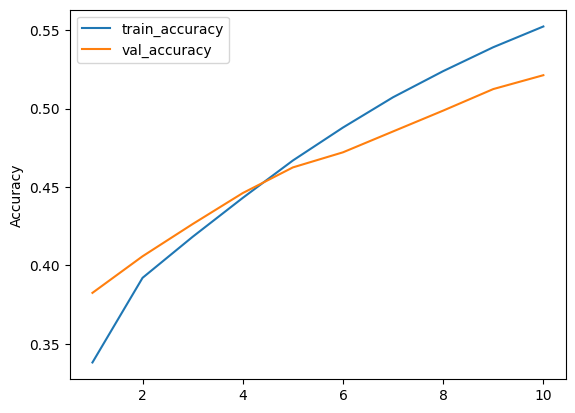

In [79]:
# Figures to visualize the training loss, test loss, training accuracy, test accuracy 
import matplotlib.pyplot as plt
epochs=range(1, len(history["train_loss"])+1)
plt.figure()
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, history["train_accuracy"], label="train_accuracy")
plt.plot(epochs, history["val_accuracy"], label="val_accuracy")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [81]:
# inverse vocabulary
id_to_word = {i: w for w, i in vocab.items()}

def decode(token_ids, id_to_word):
    words = []

    for idx in token_ids:
        word = id_to_word.get(idx, "<UNK>")

        if word == "<EOS>":
            break

        words.append(word)

    text = " ".join(words)
    text = text.replace(" ,", ",")
    text = text.replace(" .", ".")
    text = text.replace(" !", "!")
    text = text.replace(" ?", "?")
    text = text.replace(" :", ":")
    text = text.replace(" ' ", "'")

    return text.strip()


In [83]:
#Function for text generation
def generate_reply(model, text, vocab, id_to_word, device, max_new_tokens=50):
    model.eval()

    # better prompt formatting
    text = f"user: {text}\nassistant:"
    tokens = encode(text, vocab, add_eos=False)

    input_ids = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    generated_ids = input_ids.clone()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(generated_ids)

            temperature = 0.8
            top_k = 30

            next_token_logits = logits[:, -1, :]
            next_token_logits = next_token_logits / temperature

            topk_vals, topk_idx = torch.topk(next_token_logits, top_k)

            probs = torch.softmax(topk_vals, dim=-1)

            next_token_id = topk_idx.gather(
                -1,
                torch.multinomial(probs, 1)
            )

            generated_ids = torch.cat([generated_ids, next_token_id], dim=1)

            if next_token_id.item() == vocab["<EOS>"]:
                break

    new_tokens = generated_ids[0, input_ids.size(1):].tolist()
    reply = decode(new_tokens, id_to_word)

    # clean role tags from generated text
    if "assistant:" in reply:
        reply = reply.split("assistant:", 1)[1]

    if "user:" in reply:
        reply = reply.split("user:", 1)[0]

    if "assistant :" in reply:
        reply = reply.split("assistant :", 1)[1]

    if "user :" in reply:
        reply = reply.split("user :", 1)[0]

    reply = reply.strip()

    return reply


In [85]:
#Chat function
def chat():
    while True:
        user_text = input("You: ").strip()

        if user_text.lower() in ["exit", "quit"]:
            print("Chat ended.")
            break

        reply = generate_reply(model, user_text, vocab, id_to_word, device)

        # optional fallback if model returns empty text
        if reply == "":
            reply = "..."

        print("Bot:", reply)


chat()

You:  hello


Bot: good morning, sir. can i help you?


You:  how are you


Bot: fine, karen. i m just putting on a little weight, and i m really tired.


You:  you seems really smart


...

Bot: i read about how the football of football.


You:  good by


Bot: thank you for your interest in this position. i am very interested.


You:  exit


Chat ended.
